<a href="https://colab.research.google.com/github/lucasrabd/Chatbot-Sprint-3/blob/main/vibracao_preditivo_definitivo_melhor_curva_tudo_de_bom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔧 Teknikao — Modelo Preditivo de Vibração
**Pipeline:** Leitura CSV → Pré-processamento → Detecção de manutenção (t=0) → Modelo preditivo → Previsão de alerta

---

## 0. Instalação de dependências

In [ ]:
# Execute apenas uma vez
!pip install pandas numpy matplotlib scikit-learn xgboost pykalman seaborn

## 1. Configuração — edite aqui

In [ ]:
# ─────────────────────────────────────────────
#  ⚙️  EDITE ESTAS VARIÁVEIS CONFORME SEU CASO
# ─────────────────────────────────────────────

CSV_PATH      = "01-MOT-LOA-VERT.csv"  # caminho para o seu arquivo
MACHINE_ID    = "MOT-LOA-VERT"          # identificação da máquina

# Limiares (ISO 10816 — mm/s)
THRESHOLD        = 14.0    # alerta (~p95 do sinal)
THRESHOLD_DANGER = 18.5    # perigo (~p99 do sinal)

# Parâmetros de detecção de t=0
RESET_WINDOW    = 20    # amostras após descida onde busca o mínimo local
RESET_COOLDOWN  = 30.0  # segundos mínimos entre dois resets (evita duplicatas)
RESET_MAX_RATIO = 0.5   # t=0 deve estar abaixo de THRESHOLD * ratio (ex: <7 mm/s)

# Parâmetros do modelo preditivo
WINDOW_SEC       = 60    # janela de média móvel (segundos)
FORECAST_HORIZON = 600   # horizonte de previsão (segundos)

## 2. Leitura e inspeção do CSV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Leitura do CSV (formato Teknikao/OROS/exportadores industriais) ────────────
# Estrutura esperada:
#   Linha 1: metadados (u:ÁREA ...; ch1; n:4095; d:0.4; eu:mm/s; data; s:)
#   Linha 2: cabeçalho (t[s]; Y[mm/s];)
#   Linha 3+: dados

def read_teknikao_csv(path):
    encodings = ['latin-1', 'iso-8859-1', 'cp1252', 'utf-8']
    for enc in encodings:
        try:
            df = pd.read_csv(path, sep=';', decimal=',', encoding=enc,
                             header=1, index_col=False)
            time = pd.to_numeric(df.iloc[:, 0], errors='coerce')
            rms  = pd.to_numeric(df.iloc[:, 1], errors='coerce')
            result = pd.DataFrame({'time': time, 'rms': rms}).dropna().reset_index(drop=True)
            if len(result) > 10:
                print(f"✅ Encoding: {enc} | Colunas: {list(df.columns[:2])}")
                return result
        except Exception as e:
            continue
    raise ValueError("Falha na leitura. Verifique se o arquivo é do formato Teknikao.")

df = read_teknikao_csv(CSV_PATH)

# Vibração é AC — trabalha com valor absoluto (amplitude)
df['rms'] = df['rms'].abs()

# Metadados
dt       = df['time'].diff().median()
fs       = 1 / dt
duracao  = df['time'].max()

print(f"\n📊 {MACHINE_ID}")
print(f"   Amostras  : {len(df):,}")
print(f"   Duração   : {duracao:.1f}s ({duracao/60:.1f} min)")
print(f"   Frequência: {fs:.2f} Hz (1 amostra a cada {dt:.3f}s)")
print(f"   Sinal max : {df['rms'].max():.4f} mm/s")
print(f"   Sinal p95 : {df['rms'].quantile(0.95):.4f} mm/s")
print(f"   Limiar ⚠️  : {THRESHOLD} mm/s")
print(f"   Limiar 🔴 : {THRESHOLD_DANGER} mm/s")

df.head()

✅ Encoding: latin-1 | Colunas: ['t[s]', 'Y[mm/s]']

📊 MOT-LOA-VERT
   Amostras  : 4,096
   Duração   : 1638.0s (27.3 min)
   Frequência: 2.50 Hz (1 amostra a cada 0.400s)
   Sinal max : 22.8303 mm/s
   Sinal p95 : 13.9630 mm/s
   Limiar ⚠️  : 14.0 mm/s
   Limiar 🔴 : 18.5 mm/s


,time,rms
0,0.0,11.151160
1,0.4,13.864842
2,0.8,2.357314
3,1.2,11.631371
4,1.6,18.028324


## 3. Visualização do sinal bruto

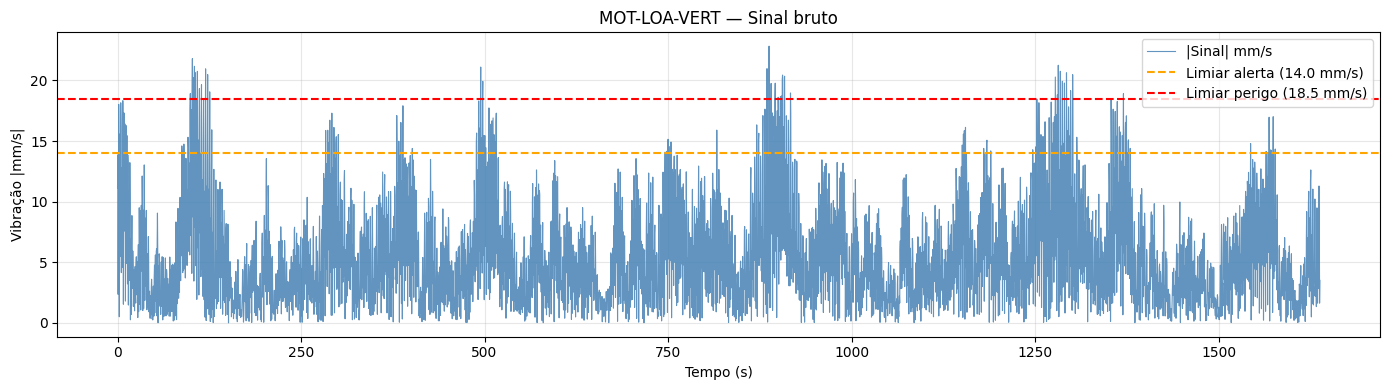

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['time'], df['rms'], color='steelblue', linewidth=0.8, alpha=0.85, label='|Sinal| mm/s')
ax.axhline(THRESHOLD,        color='orange', linestyle='--', linewidth=1.5, label=f'Limiar alerta ({THRESHOLD} mm/s)')
ax.axhline(THRESHOLD_DANGER, color='red',    linestyle='--', linewidth=1.5, label=f'Limiar perigo ({THRESHOLD_DANGER} mm/s)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Vibração |mm/s|')
ax.set_title(f'{MACHINE_ID} — Sinal bruto')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Detecção de manutenções (t=0)

🔧 Pontos t=0 detectados: 19

Ciclo   Tempo (s)    RMS (mm/s)
-----------------------------------
    1        2.40        0.5095
    2       92.40        3.7089
    3      126.40        0.1213
    4      291.20        0.6302
    5      384.00        0.0629
    6      491.20        1.9300
    7      523.60        1.0805
    8      749.20        0.8670
    9      820.00        1.6339
   10      871.60        0.5459
   11      903.60        5.1839
   12     1154.40        0.3150
   13     1187.60        0.0541
   14     1250.40        1.3846
   15     1282.40        0.5190
   16     1354.40        1.6090
   17     1384.40        1.6129
   18     1544.40        0.2412
   19     1582.00        1.0956


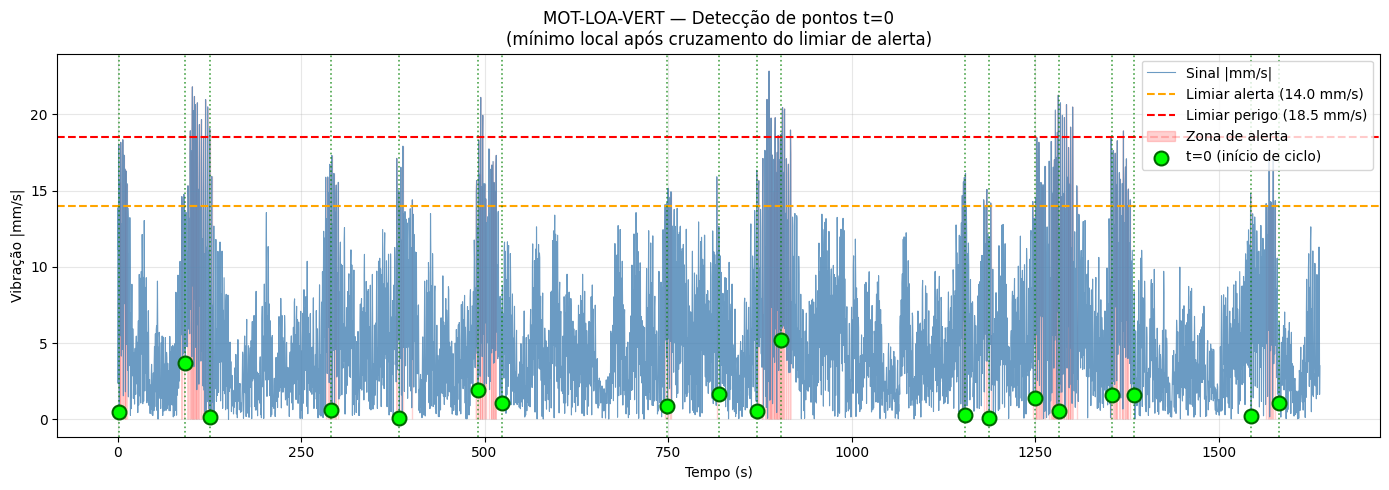

In [ ]:
def find_reset_points(time, rms, threshold,
                      window_after=20, min_gap_s=30):
    """
    Define t=0 (ponto inicial de ciclo) como:
      1. O sinal CRUZA o limiar de alerta para cima (evento de alerta)
      2. Em seguida cai abaixo do limiar
      3. O ponto t=0 é o MÍNIMO LOCAL dentro de uma janela após a descida

    Parâmetros
    ----------
    threshold   : limiar de alerta (mm/s)
    window_after: amostras à frente da descida para buscar o mínimo local
    min_gap_s   : gap mínimo em segundos entre dois pontos t=0 consecutivos
    """
    rms_arr  = rms.values
    time_arr = time.values
    n        = len(rms_arr)

    reset_indices = []
    in_alert      = False   # estamos acima do limiar?
    alert_peak_i  = None    # índice do pico dentro do alerta

    for i in range(n):
        if rms_arr[i] >= threshold:
            in_alert    = True
            alert_peak_i = i   # atualiza enquanto continua acima

        elif in_alert and rms_arr[i] < threshold:
            # Acabou de descer abaixo do limiar
            # Busca o mínimo local na janela seguinte
            end = min(i + window_after, n)
            local_min_i = i + np.argmin(rms_arr[i:end])

            # Garante gap mínimo entre resets consecutivos
            if reset_indices:
                gap = time_arr[local_min_i] - time_arr[reset_indices[-1]]
                if gap < min_gap_s:
                    in_alert = False
                    continue

            reset_indices.append(local_min_i)
            in_alert = False

    return reset_indices

# ── Detecta pontos t=0 ────────────────────────────────────────────────────────
reset_idx = find_reset_points(df['time'], df['rms'], THRESHOLD,
                               window_after=20, min_gap_s=30)

# Marca no dataframe
df['is_reset'] = False
df.loc[reset_idx, 'is_reset'] = True
df['cycle_id'] = df['is_reset'].cumsum()
df['t_cycle']  = df.groupby('cycle_id').cumcount()

reset_pts = df[df['is_reset']]
print(f"🔧 Pontos t=0 detectados: {len(reset_pts)}")
print()
if len(reset_pts) > 0:
    print(f"{'Ciclo':>5}  {'Tempo (s)':>10}  {'RMS (mm/s)':>12}")
    print("-" * 35)
    for _, row in reset_pts.iterrows():
        print(f"{int(row['cycle_id']):>5}  {row['time']:>10.2f}  {row['rms']:>12.4f}")
else:
    print("⚠️  Nenhum ponto t=0 encontrado.")
    print(f"   O sinal chegou a cruzar {THRESHOLD} mm/s?")
    print(f"   Máximo do sinal: {df['rms'].max():.4f} mm/s")
    print(f"   Tente reduzir THRESHOLD.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['time'], df['rms'], color='steelblue', lw=0.8, alpha=0.8, label='Sinal |mm/s|')
ax.axhline(THRESHOLD,        color='orange', ls='--', lw=1.5, label=f'Limiar alerta ({THRESHOLD} mm/s)')
ax.axhline(THRESHOLD_DANGER, color='red',    ls='--', lw=1.5, label=f'Limiar perigo ({THRESHOLD_DANGER} mm/s)')

# Zonas acima do limiar em vermelho
above = df['rms'] >= THRESHOLD
ax.fill_between(df['time'], 0, df['rms'], where=above,
                alpha=0.18, color='red', label='Zona de alerta')

# Marca os t=0
ax.scatter(reset_pts['time'], reset_pts['rms'],
           color='lime', edgecolors='darkgreen', zorder=6,
           s=100, linewidths=1.5, label='t=0 (início de ciclo)')

# Linhas verticais nos t=0
for _, row in reset_pts.iterrows():
    ax.axvline(row['time'], color='green', ls=':', lw=1.2, alpha=0.7)

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Vibração |mm/s|')
ax.set_title(f'{MACHINE_ID} — Detecção de pontos t=0\n'
             f'(mínimo local após cruzamento do limiar de alerta)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [ ]:
dt_val       = df['time'].diff().median()
win_samples  = max(int(WINDOW_SEC / dt_val), 5)
print(f"Janela {WINDOW_SEC}s = {win_samples} amostras | fs = {1/dt_val:.2f} Hz")

df['rms_norm']   = df['rms'] / THRESHOLD
df['pct_thresh'] = df['rms_norm'] * 100
df['ma_short']   = df['rms'].rolling(win_samples).mean()
df['ma_long']    = df['rms'].rolling(win_samples * 5).mean()
df['std_short']  = df['rms'].rolling(win_samples).std()

def rolling_slope(series, window):
    arr = series.values
    out = [np.nan] * len(arr)
    for i in range(window, len(arr)):
        y = arr[i-window:i]
        out[i] = np.polyfit(np.arange(window), y, 1)[0]
    return out

df['slope'] = rolling_slope(df['rms'], win_samples)

df_feat = df.dropna().copy()
print(f"✅ {len(df_feat):,} amostras válidas com features")
df_feat[['time','rms','rms_norm','pct_thresh','ma_short','slope']].tail()

Janela 60s = 149 amostras | fs = 2.50 Hz
✅ 3,352 amostras válidas com features


,time,rms,rms_norm,pct_thresh,ma_short,slope
4091,1636.400024,8.478711,0.605622,60.562222,3.990727,0.005344
4092,1636.800024,11.295085,0.806792,80.679178,3.970246,0.009181
4093,1637.200024,9.443774,0.674555,67.455530,4.001149,0.013959
4094,1637.600024,1.633061,0.116647,11.664723,3.977228,0.015665
4095,1638.000024,3.512906,0.250922,25.092183,3.943509,0.015355


## 6. Suavização Kalman (para sinais ruidosos)

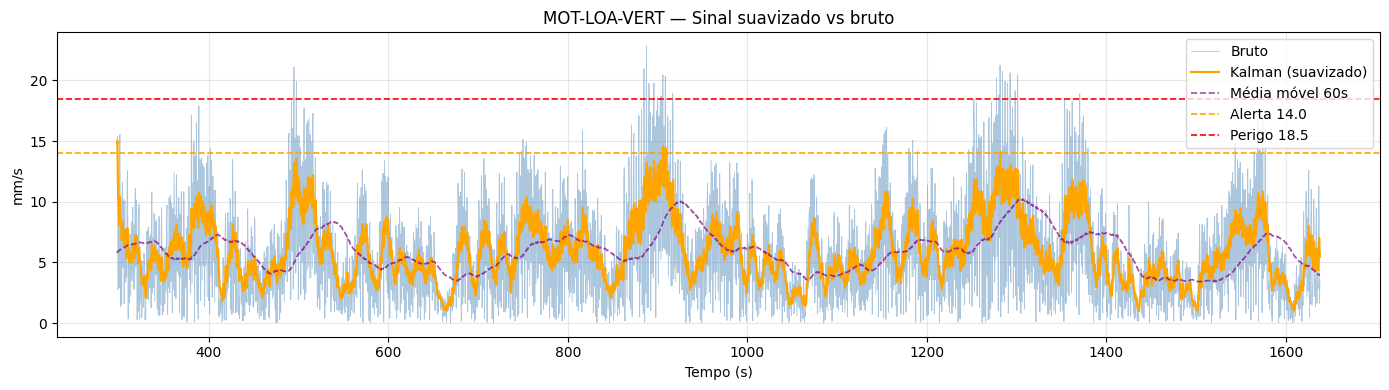

In [ ]:
from pykalman import KalmanFilter

kf = KalmanFilter(
    transition_matrices=[1], observation_matrices=[1],
    initial_state_mean=df_feat['rms'].iloc[0],
    initial_state_covariance=1,
    observation_covariance=1.0,
    transition_covariance=0.05
)
state_means, _ = kf.filter(df_feat['rms'].values)
df_feat = df_feat.copy()
df_feat['rms_kalman'] = state_means.flatten()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_feat['time'], df_feat['rms'],        color='steelblue', linewidth=0.6, alpha=0.45, label='Bruto')
ax.plot(df_feat['time'], df_feat['rms_kalman'], color='orange',    linewidth=1.6, label='Kalman (suavizado)')
ax.plot(df_feat['time'], df_feat['ma_short'],   color='purple',    linewidth=1.2, linestyle='--', alpha=0.7, label=f'Média móvel {WINDOW_SEC}s')
ax.axhline(THRESHOLD,        color='orange', linestyle='--', linewidth=1.2, label=f'Alerta {THRESHOLD}')
ax.axhline(THRESHOLD_DANGER, color='red',    linestyle='--', linewidth=1.2, label=f'Perigo {THRESHOLD_DANGER}')
ax.set_xlabel('Tempo (s)'); ax.set_ylabel('mm/s')
ax.set_title(f'{MACHINE_ID} — Sinal suavizado vs bruto')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Target — tempo até cruzar o limiar de alerta

In [ ]:
def compute_target(rms_arr, time_arr, threshold, horizon):
    targets = np.full(len(rms_arr), np.nan)
    for i in range(len(rms_arr)):
        if rms_arr[i] >= threshold:
            targets[i] = 0.0
            continue
        t0   = time_arr[i]
        mask = (time_arr > t0) & (time_arr <= t0 + horizon) & (rms_arr >= threshold)
        if mask.any():
            targets[i] = time_arr[mask][0] - t0
    return targets

df_feat = df_feat.copy()
df_feat['target_s'] = compute_target(
    df_feat['rms'].values, df_feat['time'].values,
    THRESHOLD, FORECAST_HORIZON
)

df_model = df_feat.dropna(subset=['target_s'])
print(f"✅ Amostras com target: {len(df_model):,} ({100*len(df_model)/len(df_feat):.1f}%)")
print(f"   Target min: {df_model['target_s'].min():.1f}s | max: {df_model['target_s'].max():.1f}s")

if len(df_model) < 30:
    print("\n⚠️  Poucos cruzamentos do limiar detectados.")
    print(f"   Sugestão: reduza THRESHOLD para ~{df_feat['rms'].quantile(0.90):.1f} mm/s (p90 atual)")

✅ Amostras com target: 3,200 (95.5%)
   Target min: 0.0s | max: 233.2s


## 8. Treinamento do modelo preditivo

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

FEATURES = ['rms_norm', 'pct_thresh', 'ma_short', 'std_short', 'slope', 'rms_kalman', 't_cycle']

X = df_model[FEATURES].values
y = df_model['target_s'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_xgb = xgb.predict(X_test)

lr = LinearRegression().fit(X_train, y_train)
y_lr = lr.predict(X_test)

mae_xgb, r2_xgb = mean_absolute_error(y_test, y_xgb), r2_score(y_test, y_xgb)
mae_lr,  r2_lr  = mean_absolute_error(y_test, y_lr),  r2_score(y_test, y_lr)

print("📊 Resultados no teste:")
print(f"   XGBoost  — MAE: {mae_xgb:.1f}s  R²: {r2_xgb:.3f}")
print(f"   Linear   — MAE: {mae_lr:.1f}s   R²: {r2_lr:.3f}")

best_model = xgb if r2_xgb >= r2_lr else lr
best_name  = 'XGBoost' if r2_xgb >= r2_lr else 'Linear'
print(f"\n✅ Modelo selecionado: {best_name}")

📊 Resultados no teste:
   XGBoost  — MAE: 11.7s  R²: 0.897
   Linear   — MAE: 45.6s   R²: 0.194

✅ Modelo selecionado: XGBoost


## 9. Avaliação visual

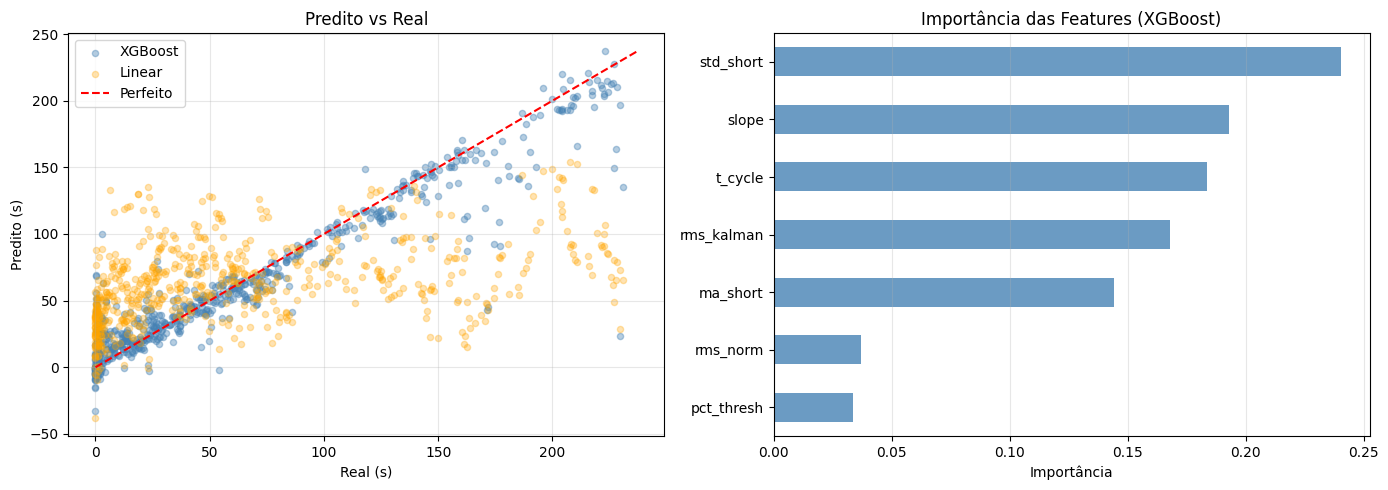

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_xgb, alpha=0.4, color='steelblue', s=20, label='XGBoost')
ax1.scatter(y_test, y_lr,  alpha=0.3, color='orange',    s=20, label='Linear')
lim = max(y_test.max(), y_xgb.max())
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfeito')
ax1.set_xlabel('Real (s)'); ax1.set_ylabel('Predito (s)')
ax1.set_title('Predito vs Real'); ax1.legend(); ax1.grid(alpha=0.3)

imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(ax=ax2, color='steelblue', alpha=0.8)
ax2.set_title('Importância das Features (XGBoost)')
ax2.set_xlabel('Importância'); ax2.grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

## 10. Diagnóstico — estado atual da máquina

In [ ]:
def alert_label(s):
    if s <= 0:     return "🔴 LIMIAR ATINGIDO — MANUTENÇÃO IMEDIATA"
    elif s <= 300: return "🔴 CRÍTICO (< 5 min)"
    elif s <= 3600:return "🟡 ATENÇÃO (< 1h)"
    elif s <= 86400:return"🟡 PREVENTIVO (< 24h)"
    else:          return "🟢 NORMAL"

last = df_feat.dropna(subset=FEATURES).iloc[-1]
X_now = last[FEATURES].values.reshape(1, -1)
rms_now = last['rms']

sec_pred = max(0.0, float(best_model.predict(X_now)[0])) if rms_now < THRESHOLD else 0.0

print("=" * 56)
print(f"  🏭  {MACHINE_ID}")
print("=" * 56)
print(f"  Sinal atual    : {rms_now:.4f} mm/s")
print(f"  Limiar alerta  : {THRESHOLD} mm/s")
print(f"  Limiar perigo  : {THRESHOLD_DANGER} mm/s")
print(f"  % do limiar    : {100*rms_now/THRESHOLD:.1f}%")
print(f"  Slope atual    : {last['slope']:.5f} mm/s por amostra")
print("-" * 56)
if sec_pred < 3600:
    print(f"  ⏱  Tempo previsto: {sec_pred/60:.1f} min")
else:
    print(f"  ⏱  Tempo previsto: {sec_pred/3600:.1f}h ({sec_pred/60:.0f} min)")
print(f"  Modelo         : {best_name}")
print("-" * 56)
print(f"  {alert_label(sec_pred)}")
print("=" * 56)

  🏭  MOT-LOA-VERT
  Sinal atual    : 3.5129 mm/s
  Limiar alerta  : 14.0 mm/s
  Limiar perigo  : 18.5 mm/s
  % do limiar    : 25.1%
  Slope atual    : 0.01535 mm/s por amostra
--------------------------------------------------------
  ⏱  Tempo previsto: 1.7 min
  Modelo         : XGBoost
--------------------------------------------------------
  🔴 CRÍTICO (< 5 min)


## 11. Timeline preditiva completa

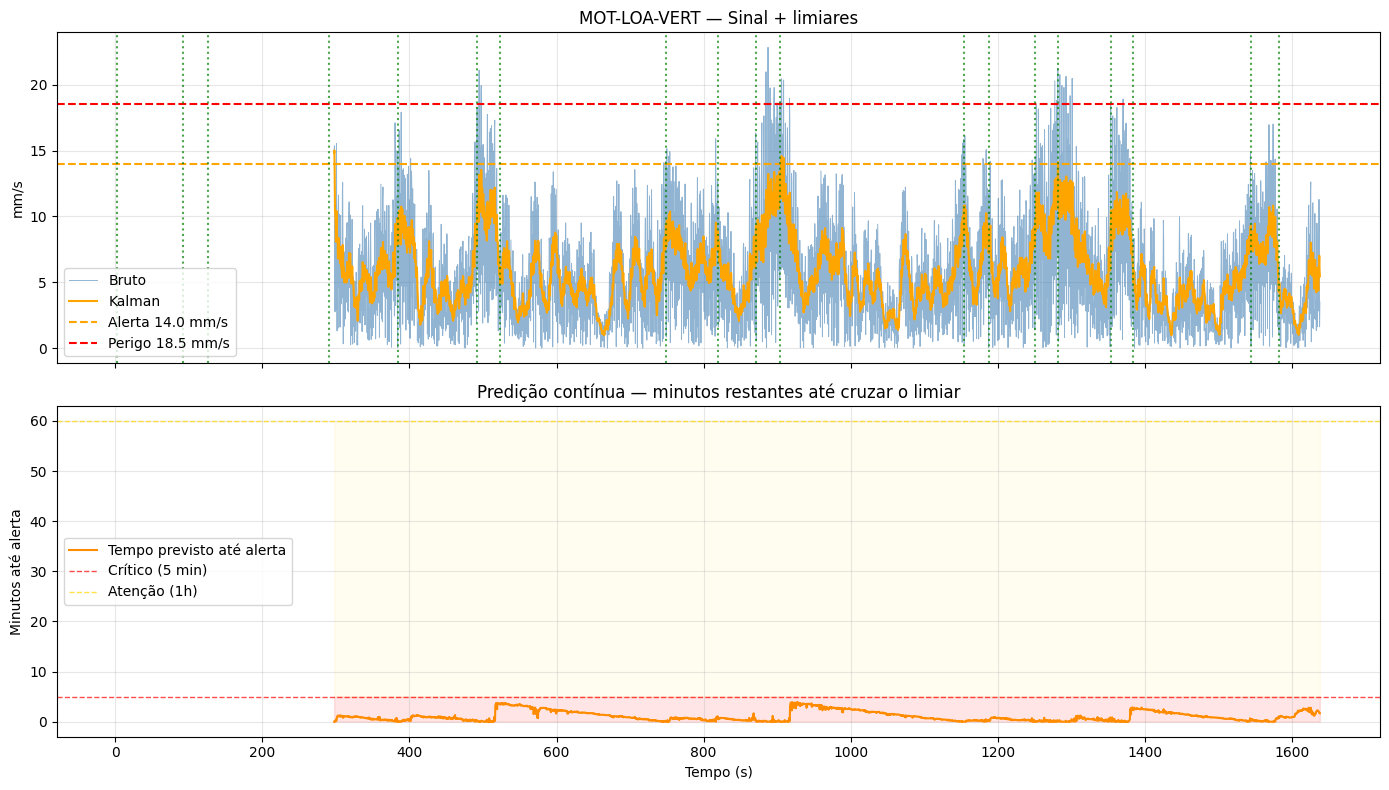

In [ ]:
df_plot = df_feat.dropna(subset=FEATURES).copy()
df_plot['pred_s']   = np.clip(best_model.predict(df_plot[FEATURES].values), 0, None)
df_plot['pred_min'] = df_plot['pred_s'] / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df_plot['time'], df_plot['rms'],        color='steelblue', lw=0.7, alpha=0.6, label='Bruto')
ax1.plot(df_plot['time'], df_plot['rms_kalman'], color='orange',    lw=1.5, label='Kalman')
ax1.axhline(THRESHOLD,        color='orange', ls='--', lw=1.5, label=f'Alerta {THRESHOLD} mm/s')
ax1.axhline(THRESHOLD_DANGER, color='red',    ls='--', lw=1.5, label=f'Perigo {THRESHOLD_DANGER} mm/s')
for _, row in df[df['is_reset']].iterrows():
    ax1.axvline(row['time'], color='green', ls=':', lw=1.5, alpha=0.7)
ax1.set_ylabel('mm/s'); ax1.set_title(f'{MACHINE_ID} — Sinal + limiares')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(df_plot['time'], df_plot['pred_min'], color='darkorange', lw=1.5, label='Tempo previsto até alerta')
ax2.axhline(5,  color='red',    ls='--', lw=1.0, alpha=0.7, label='Crítico (5 min)')
ax2.axhline(60, color='gold',   ls='--', lw=1.0, alpha=0.7, label='Atenção (1h)')
ax2.fill_between(df_plot['time'], 0, 5,  alpha=0.10, color='red')
ax2.fill_between(df_plot['time'], 5, 60, alpha=0.06, color='gold')
ax2.set_xlabel('Tempo (s)'); ax2.set_ylabel('Minutos até alerta')
ax2.set_title('Predição contínua — minutos restantes até cruzar o limiar')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Salvar modelo

In [ ]:
import joblib
path = f"modelo_{MACHINE_ID.replace(' ','_').replace('/','_')}.pkl"
joblib.dump({'model': best_model, 'features': FEATURES, 'threshold': THRESHOLD,
             'threshold_danger': THRESHOLD_DANGER, 'machine_id': MACHINE_ID}, path)
print(f"✅ Modelo salvo: {path}")
print(f"   Carregar: obj = joblib.load('{path}'); model = obj['model']")

✅ Modelo salvo: modelo_MOT-LOA-VERT.pkl
   Carregar: obj = joblib.load('modelo_MOT-LOA-VERT.pkl'); model = obj['model']
